# Recency- and Cadence-Aware Hybrid Basket Completion
### IA-2 — Advanced Data Analytics (216H03C701), Semester VII, AY 2026–27

**Approved problem statement**

> **Identifying complementary and potentially missing grocery products in a customer's shopping basket using frequent itemset mining, association rules, purchase history, and recency-aware recommendation.**

## Research motivation and gap

```text
Traditional Market Basket Analysis
              ↓
       Association Rules
              ↓
Limitation: does not model temporal behaviour
or individual replenishment patterns
              ↓
     Sequential / Next-Basket Research
              ↓
Limitation: can be complex and less interpretable
              ↓
      Our Proposed Hybrid Approach
```

Basket-level mining answers *what products occur together*, while next-basket research asks *what purchasing patterns recur across subsequent shopping trips*. Grocery recommendation also has a strong repeat-purchase component. This notebook therefore treats Apriori and FP-Growth as transparent baselines, then evaluates a lightweight hybrid that combines complementary-product associations, sequential behaviour, customer history, and personalized cadence.

**Research question:** Can a lightweight hybrid of basket associations, sequential purchase patterns, and personalized cadence improve identification of complementary and potentially missing grocery products compared with conventional market-basket recommendation?

**Contribution:** We propose and experimentally evaluate an interpretable framework that separates complementary discovery from replenishment, distinguishes repeat from explore recommendations, and uses ablation experiments to measure which signals help.

### End-to-end workflow
1. Load and validate the public Instacart data.
2. Explore basket, reorder, and customer-sequence behaviour.
3. Build a leakage-resistant mining/validation split.
4. Establish popularity, Apriori, and FP-Growth baselines.
5. Generate complementary candidates with association rules.
6. Mine compact sequential patterns across consecutive orders.
7. Calculate purchase frequency, intervals, recency, and personalized cadence.
8. Separate repeat/replenishment and explore/complement candidates.
9. Rank candidates with a normalized hybrid score.
10. Compare baselines and ablations using ranking, coverage, diversity, novelty, and replenishment metrics.
11. Analyze scalability, limitations, responsible AI, and future work.

> **Scope note:** This is an academic analogue of Instacart's recommendation problem. Public Instacart documentation does not disclose Apriori, FP-Growth, or this exact hybrid as its production implementation.



## 1. Install dependencies

The notebook is designed for Google Colab or a normal Python/Jupyter environment.

If automatic dataset download is unavailable, download the Instacart Market Basket Analysis CSV files and place them under `data/instacart/` or set `INSTACART_DATA_DIR` to the directory containing the CSV files.


In [19]:
%pip -q install "mlxtend>=0.23" "kagglehub>=0.3" "psutil>=5.9"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from __future__ import annotations

import os
import platform
import random
import time
import warnings
import zipfile
import hashlib
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns

from IPython.display import display
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42

# Resource controls. Increase these only if your runtime has enough RAM/CPU.
MAX_ORDERS = 30_000
TOP_N_PRODUCTS = 250

MIN_SUPPORT = 0.003
MIN_CONFIDENCE = 0.10
MIN_LIFT = 1.05
MAX_ITEMSET_LEN = 3

TOP_K = 10

random.seed(SEED)
np.random.seed(SEED)

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "ram_gb": round(psutil.virtual_memory().total / 2**30, 1),
    "seed": SEED,
})

{'python': '3.14.6', 'pandas': '3.0.5', 'ram_gb': 15.7, 'seed': 42}


## 2. Load the Instacart Market Basket Analysis data

Required files:

- `orders.csv`
- `products.csv`
- `aisles.csv`
- `departments.csv`
- `order_products__prior.csv`
- `order_products__train.csv`

The public Kaggle competition dataset is used as the academic data source. The code first looks for a local directory, then tries a public GitHub bundle, Kaggle, and finally a public mirror.


In [21]:
REQUIRED = {
    "orders.csv",
    "products.csv",
    "aisles.csv",
    "departments.csv",
    "order_products__prior.csv",
    "order_products__train.csv",
}

def locate_csv_dir(root: Path) -> Path | None:
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for candidate in candidates:
        if REQUIRED.issubset({p.name for p in candidate.glob("*.csv")}):
            return candidate
    return None

DATA_ROOT = Path(os.environ.get("INSTACART_DATA_DIR", str(Path.cwd() / "data")))
DATA_ROOT.mkdir(parents=True, exist_ok=True)
DATA_DIR = locate_csv_dir(DATA_ROOT)

BUNDLE_NAME = "instacart-market-basket-analysis-data.zip"
BUNDLE_SHA256 = "b0c58b80af5c43bcdebf34909033b740fc312353d2b8aa5f442083c824e8311d"
BUNDLE_URL = (
    "https://github.com/shreejaykurhade/instacart-frequent-itemset-mining/"
    f"releases/download/dataset-v1/{BUNDLE_NAME}"
)

if DATA_DIR is None:
    try:
        bundle = Path.cwd() / BUNDLE_NAME
        if not bundle.exists():
            bundle = DATA_ROOT / BUNDLE_NAME
        if not bundle.exists():
            print("Downloading dataset bundle...")
            urlretrieve(BUNDLE_URL, bundle)

        with bundle.open("rb") as stream:
            digest = hashlib.file_digest(stream, "sha256").hexdigest()

        if digest != BUNDLE_SHA256:
            raise ValueError("Dataset bundle checksum mismatch.")

        with zipfile.ZipFile(bundle) as archive:
            if set(archive.namelist()) != REQUIRED:
                raise ValueError("Dataset bundle contains unexpected filenames.")
            archive.extractall(DATA_ROOT)

        DATA_DIR = locate_csv_dir(DATA_ROOT)
        print("Verified and extracted:", DATA_DIR)
    except Exception as exc:
        print("GitHub bundle unavailable:", exc)

if DATA_DIR is None:
    try:
        import kagglehub

        downloaded = Path(
            kagglehub.competition_download("instacart-market-basket-analysis")
        )

        if downloaded.is_file() and downloaded.suffix == ".zip":
            extract_to = DATA_ROOT / "instacart"
            extract_to.mkdir(exist_ok=True)
            with zipfile.ZipFile(downloaded) as archive:
                archive.extractall(extract_to)
            DATA_DIR = locate_csv_dir(extract_to)
        else:
            DATA_DIR = locate_csv_dir(downloaded)

        print("Kaggle data:", DATA_DIR)
    except Exception as exc:
        print("Kaggle download unavailable:", exc)

if DATA_DIR is None:
    try:
        mirror = (
            "https://huggingface.co/datasets/attik/"
            "Instacart-Market-Basket-Analysis/resolve/main"
        )
        mirror_dir = DATA_ROOT / "instacart"
        mirror_dir.mkdir(exist_ok=True)

        for filename in sorted(REQUIRED):
            destination = mirror_dir / filename
            if not destination.exists():
                print("Downloading:", filename)
                urlretrieve(f"{mirror}/{filename}", destination)

        DATA_DIR = locate_csv_dir(mirror_dir)
    except Exception as exc:
        print("Public mirror unavailable:", exc)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Instacart CSVs not found. Upload/unzip the Kaggle archive under "
        f"{DATA_ROOT} or set INSTACART_DATA_DIR. Required: {sorted(REQUIRED)}"
    )

print("Using data from:", DATA_DIR)

Using data from: c:\Users\hp\OneDrive\Projects\instacart-frequent-itemset-mining\data\instacart


In [22]:
orders = pd.read_csv(
    DATA_DIR / "orders.csv",
    dtype={
        "order_id": "int32",
        "user_id": "int32",
        "eval_set": "category",
        "order_number": "int16",
        "order_dow": "int8",
        "order_hour_of_day": "int8",
        "days_since_prior_order": "float32",
    },
)

products = pd.read_csv(
    DATA_DIR / "products.csv",
    dtype={"product_id": "int32", "aisle_id": "int16", "department_id": "int8"},
)

aisles = pd.read_csv(DATA_DIR / "aisles.csv", dtype={"aisle_id": "int16"})
departments = pd.read_csv(
    DATA_DIR / "departments.csv", dtype={"department_id": "int8"}
)

prior = pd.read_csv(
    DATA_DIR / "order_products__prior.csv",
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    },
)

train = pd.read_csv(
    DATA_DIR / "order_products__train.csv",
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    },
)

assert orders.order_id.is_unique
assert products.product_id.is_unique
assert set(prior.order_id).issubset(set(orders.order_id))
assert prior[["order_id", "product_id"]].duplicated().sum() == 0

summary = pd.DataFrame({
    "table": ["orders", "prior items", "train items", "products", "users"],
    "rows_or_count": [
        len(orders),
        len(prior),
        len(train),
        len(products),
        orders.user_id.nunique(),
    ],
})

display(summary.style.format({"rows_or_count": "{:,}"}))

,table,rows_or_count
0,orders,"3,421,083"
1,prior items,"32,434,489"
2,train items,"1,384,617"
3,products,"49,688"
4,users,"206,209"


## 3. Dataset, research context, and customer sequences

The core recommendation signals available in the public dataset include:

- **Basket composition:** products bought together in the same order.
- **Customer history:** previous orders of the same user.
- **Order sequence:** `order_number`.
- **Inter-order timing:** `days_since_prior_order`.
- **Reorder behavior:** the `reordered` field.

The goal is not to reproduce Instacart's entire marketplace. The goal is to model the approved business problem: identify useful complementary or potentially missing products for a customer.



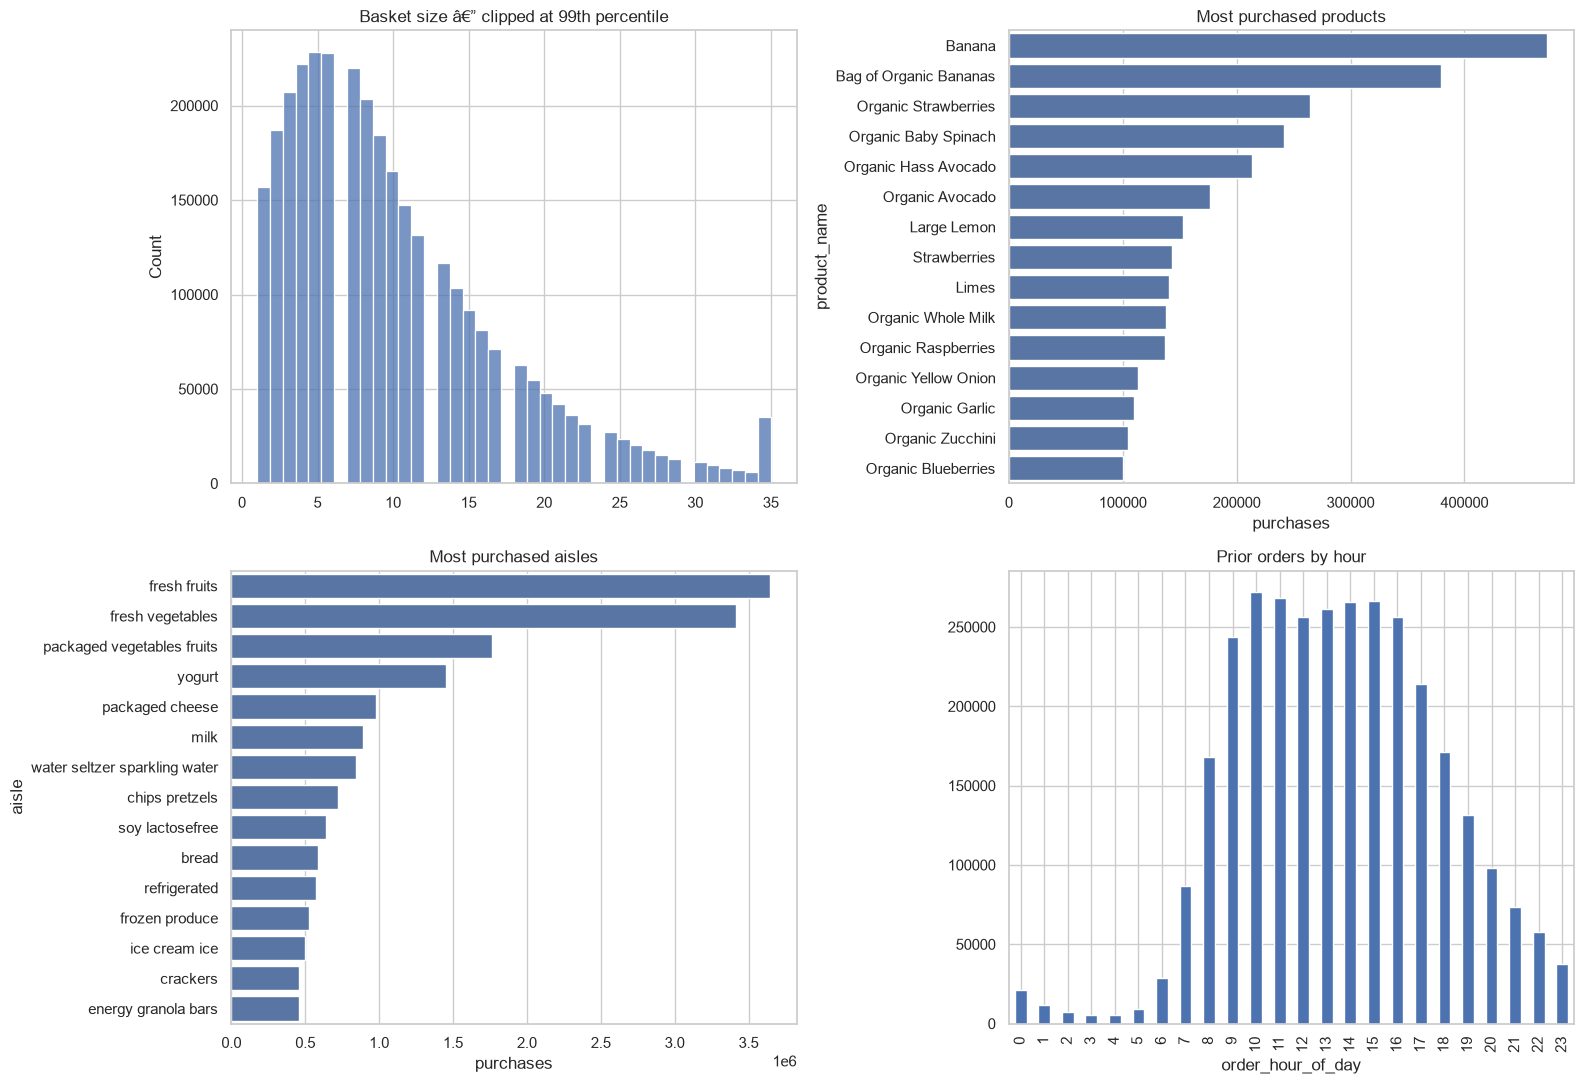

Median basket size: 8.0
Prior-item reorder rate: 0.5897


In [23]:
product_dim = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

prior_orders = orders.loc[
    orders.eval_set == "prior",
    ["order_id", "user_id", "order_number", "order_dow", "order_hour_of_day",
     "days_since_prior_order"],
]

prior_named = prior.merge(product_dim, on="product_id", how="left")

basket_sizes = prior.groupby("order_id", observed=True).size()

top_products = (
    prior_named.groupby(["product_id", "product_name"], observed=True)
    .size()
    .sort_values(ascending=False)
    .head(15)
    .rename("purchases")
    .reset_index()
)

top_aisles = (
    prior_named.groupby("aisle", observed=True)
    .size()
    .sort_values(ascending=False)
    .head(15)
    .rename("purchases")
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.histplot(
    basket_sizes.clip(upper=basket_sizes.quantile(.99)),
    bins=40,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Basket size â€” clipped at 99th percentile")

sns.barplot(data=top_products, y="product_name", x="purchases", ax=axes[0, 1])
axes[0, 1].set_title("Most purchased products")

sns.barplot(data=top_aisles, y="aisle", x="purchases", ax=axes[1, 0])
axes[1, 0].set_title("Most purchased aisles")

hourly = prior_orders.groupby("order_hour_of_day", observed=True).size()
hourly.plot(kind="bar", ax=axes[1, 1], title="Prior orders by hour")

plt.tight_layout()
plt.show()

print("Median basket size:", basket_sizes.median())
print("Prior-item reorder rate:", round(prior.reordered.mean(), 4))

## 4. Leakage-resistant development split

For each selected user, the **last prior order** is held out as the target basket.

- Earlier orders â†’ mining/history
- Last prior order â†’ validation target

This means the target basket is not used to create its own association rules or customer-history features.

The split is especially important because the project claims to predict a customer's next/held-out shopping basket.


In [24]:
last_prior = prior_orders.groupby(
    "user_id", observed=True
)["order_number"].transform("max")

order_split = prior_orders.assign(
    split=np.where(
        prior_orders.order_number.eq(last_prior),
        "validation",
        "mining",
    )
)

eligible_users = order_split.groupby("user_id", observed=True).size()
eligible_users = eligible_users[eligible_users >= 2].index.to_numpy()

rng = np.random.default_rng(SEED)

sampled_users = rng.choice(
    eligible_users,
    size=min(len(eligible_users), max(2_000, MAX_ORDERS // 5)),
    replace=False,
)

sampled_meta = order_split[order_split.user_id.isin(sampled_users)].copy()

# Keep all earlier orders for sampled users available for history.
mining_ids_all = sampled_meta.loc[
    sampled_meta.split == "mining", "order_id"
].to_numpy()

# Bound the global mining workload.
mining_ids = rng.choice(
    mining_ids_all,
    size=min(MAX_ORDERS, len(mining_ids_all)),
    replace=False,
)

validation_ids = sampled_meta.loc[
    sampled_meta.split == "validation", "order_id"
].to_numpy()

mining_items = prior[prior.order_id.isin(mining_ids)].copy()
validation_items = prior[prior.order_id.isin(validation_ids)].copy()

popular_ids = (
    mining_items.product_id
    .value_counts()
    .head(TOP_N_PRODUCTS)
    .index
)

mining_top = mining_items[
    mining_items.product_id.isin(popular_ids)
].copy()

name_map = product_dim.set_index("product_id").product_name.to_dict()

print({
    "mining_orders": mining_top.order_id.nunique(),
    "validation_orders": validation_items.order_id.nunique(),
    "products_retained": mining_top.product_id.nunique(),
    "mining_rows": len(mining_top),
})

{'mining_orders': 24423, 'validation_orders': 6000, 'products_retained': 250, 'mining_rows': 101746}


## 5. Sparse basket representation

Rows are orders and columns are retained products.

A sparse matrix is used because most products do not occur in most baskets.


In [25]:
basket = pd.crosstab(
    mining_top.order_id,
    mining_top.product_id
).astype(bool)

basket = basket.astype(pd.SparseDtype(bool, fill_value=False))
basket.columns = basket.columns.map(name_map)

density = float(basket.sparse.density)

print("Basket shape:", basket.shape)
print("Matrix density:", f"{density:.4%}")
print(
    "Sparse memory (MB):",
    round(basket.memory_usage(deep=True).sum() / 2**20, 2),
)

Basket shape: (24423, 250)
Matrix density: 1.6664%
Sparse memory (MB): 0.58


## 6. Frequent itemset mining â€” Apriori vs FP-Growth

Both algorithms receive the same transactions and thresholds.

- **Apriori:** explicit candidate-generation approach; useful for teaching and interpretability.
- **FP-Growth:** compresses frequent-pattern information and avoids the same style of repeated candidate generation.

The runtime benchmark below is only a benchmark for this sample and runtime, not a universal statement about which algorithm is always faster.


In [26]:
def timed_mine(function, matrix, **kwargs):
    start = time.perf_counter()
    result = function(matrix, **kwargs)
    return result, time.perf_counter() - start

params = dict(
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_ITEMSET_LEN,
    low_memory=True,
)

apriori_sets, apriori_seconds = timed_mine(
    apriori, basket, **params
)

fp_params = {
    k: v for k, v in params.items()
    if k != "low_memory"
}

fp_sets, fpgrowth_seconds = timed_mine(
    fpgrowth, basket, **fp_params
)

def canonical(df):
    return {
        (tuple(sorted(items)), round(float(support), 10))
        for support, items in zip(df.support, df.itemsets)
    }

agreement = canonical(apriori_sets) == canonical(fp_sets)

benchmark = pd.DataFrame({
    "algorithm": ["Apriori", "FP-Growth"],
    "seconds": [apriori_seconds, fpgrowth_seconds],
    "frequent_itemsets": [len(apriori_sets), len(fp_sets)],
})

display(benchmark)
print("Algorithms return identical itemsets/supports:", agreement)

assert agreement, (
    "Apriori and FP-Growth returned different itemsets/supports. "
    "Check package version and input matrix."
)

,algorithm,seconds,frequent_itemsets
0,Apriori,0.895595,707
1,FP-Growth,0.500318,707


Algorithms return identical itemsets/supports: True


## 7. Generate association rules

Rules are used as the **candidate retrieval layer**.

Example:

`{Milk, Bread} â†’ {Butter}`

Interpretation:

> When Milk and Bread are present in a basket, Butter has an observed association with that combination.

We use:

- **Support** â€” how often the whole rule pattern occurs.
- **Confidence** â€” how often the consequent occurs when the antecedent occurs.
- **Lift** â€” how much stronger the relationship is than the consequent's baseline frequency.

A one-product consequent matches the next-item/product-completion task.


In [27]:
rules = association_rules(
    fp_sets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE,
)

rules = rules[
    (rules.lift >= MIN_LIFT)
    & (rules.consequents.map(len) == 1)
    & np.isfinite(rules.lift)
].copy()

rules["antecedent"] = rules.antecedents.map(
    lambda x: tuple(sorted(x))
)

rules["consequent"] = rules.consequents.map(
    lambda x: next(iter(x))
)

# Rule-only retrieval score.
rules["rule_score"] = (
    rules.confidence
    * np.log1p(rules.lift)
    * np.sqrt(rules.support)
)

rules = rules.sort_values(
    ["rule_score", "support"],
    ascending=False,
)

display(
    rules[
        [
            "antecedent",
            "consequent",
            "support",
            "confidence",
            "lift",
            "leverage",
            "conviction",
            "rule_score",
        ]
    ]
    .head(25)
    .style
    .format(precision=4)
)

,antecedent,consequent,support,confidence,lift,leverage,conviction,rule_score
251,"('Total 2% Lowfat Greek Strained Yogurt With Blueberry',)",Total 2% with Strawberry Lowfat Greek Strained Yogurt,0.0051,0.5869,42.5304,0.0050,2.3871,0.1584
252,"('Total 2% with Strawberry Lowfat Greek Strained Yogurt',)",Total 2% Lowfat Greek Strained Yogurt With Blueberry,0.0051,0.3709,42.5304,0.0050,1.5758,0.1001
253,"('Total 2% Lowfat Greek Strained Yogurt With Blueberry',)",Total 2% Lowfat Greek Strained Yogurt with Peach,0.0036,0.4178,43.0587,0.0036,1.7011,0.0955
213,"('Total 2% Lowfat Greek Strained Yogurt with Peach',)",Total 2% with Strawberry Lowfat Greek Strained Yogurt,0.0041,0.4219,30.5788,0.0040,1.7061,0.0932
254,"('Total 2% Lowfat Greek Strained Yogurt with Peach',)",Total 2% Lowfat Greek Strained Yogurt With Blueberry,0.0036,0.3755,43.0587,0.0036,1.5874,0.0858
483,"('Total 2% Greek Strained Yogurt with Cherry 5.3 oz',)",Total 2% with Strawberry Lowfat Greek Strained Yogurt,0.0032,0.3578,25.9303,0.0031,1.5357,0.0666
212,"('Total 2% with Strawberry Lowfat Greek Strained Yogurt',)",Total 2% Lowfat Greek Strained Yogurt with Peach,0.0041,0.2967,30.5788,0.0040,1.4081,0.0656
139,"('Organic Avocado',)",Banana,0.0228,0.3194,1.7361,0.0097,1.1990,0.0485
178,"('Organic Fuji Apple',)",Banana,0.0133,0.3741,2.0337,0.0067,1.3038,0.0478
370,"('Honeycrisp Apple',)",Banana,0.0117,0.3818,2.0756,0.0061,1.3201,0.0464


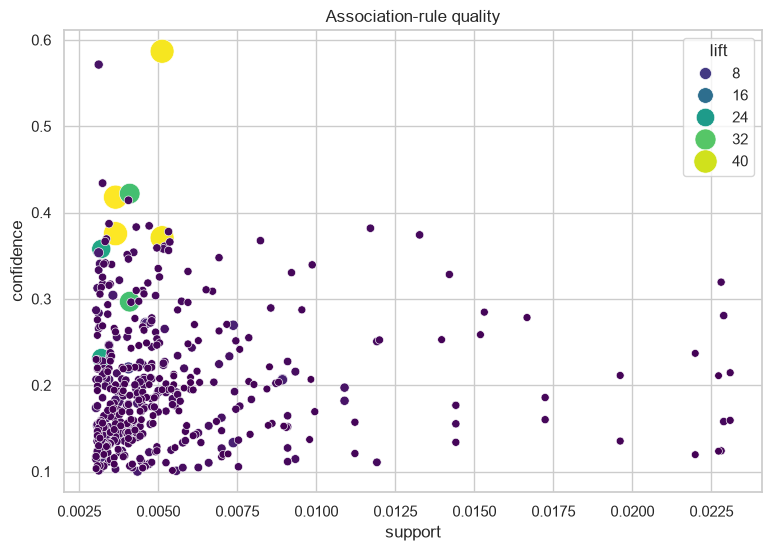

Number of usable rules: 464


In [28]:
fig, ax = plt.subplots(figsize=(9, 6))

if len(rules):
    sns.scatterplot(
        data=rules,
        x="support",
        y="confidence",
        size="lift",
        hue="lift",
        palette="viridis",
        sizes=(30, 300),
        ax=ax,
    )

ax.set_title("Association-rule quality")
plt.show()

print("Number of usable rules:", len(rules))

### Interpretation caution

High confidence can occur because a consequent is already popular. Lift helps correct for baseline popularity, while support prevents over-focusing on extremely rare patterns.

These statistics show **association**, not causation.


In [29]:
def recommend_rule_only(items, rule_frame=rules, k=10):
    """Retrieve complementary products using association rules only."""
    basket_set = set(items)

    candidates = rule_frame[
        rule_frame.antecedent.map(
            lambda a: set(a).issubset(basket_set)
        )
        & ~rule_frame.consequent.isin(basket_set)
    ].copy()

    if candidates.empty:
        return pd.DataFrame(
            columns=[
                "product_id",
                "product",
                "rule_score",
                "confidence",
                "lift",
            ]
        )

    result = (
        candidates
        .groupby("consequent", as_index=False)
        .agg(
            rule_score=("rule_score", "max"),
            confidence=("confidence", "max"),
            lift=("lift", "max"),
        )
        .sort_values("rule_score", ascending=False)
        .head(k)
        .rename(columns={"consequent": "product_id"})
    )

    result["product"] = result.product_id.map(name_map)
    return result[
        ["product_id", "product", "rule_score", "confidence", "lift"]
    ]

example_items = list(rules.iloc[0].antecedent) if len(rules) else []
print("Example basket:", example_items)
display(recommend_rule_only(example_items, k=TOP_K))

Example basket: ['Total 2% Lowfat Greek Strained Yogurt With Blueberry']


,product_id,product,rule_score,confidence,lift
1,Total 2% with Strawberry Lowfat Greek Strained...,NaN,0.158426,0.586854,42.530405
0,Total 2% Lowfat Greek Strained Yogurt with Peach,NaN,0.095484,0.417840,43.058715


# 8. Customer purchase history and recency

This is the key extension required by the approved problem statement.

For each customer/product pair we calculate:

### Frequency
How many previous orders of the customer contained the product.

### Customer frequency ratio
The fraction of the customer's previous orders containing the product.

### Reorder tendency
The average `reordered` signal for that customer's previous purchases of the product.

### Recency
How many days have elapsed since the customer last purchased the product.

To calculate recency, we reconstruct an approximate customer shopping timeline from `days_since_prior_order`.

**Leakage rule:** only orders before the validation target are used to create customer-history features.


In [30]:
# Reconstruct an approximate elapsed-day timeline for each user's prior orders.
timeline = prior_orders.sort_values(
    ["user_id", "order_number"]
).copy()

timeline["gap_days"] = timeline["days_since_prior_order"].fillna(0).astype(float)

timeline["elapsed_days"] = (
    timeline.groupby("user_id", observed=True)["gap_days"]
    .cumsum()
)

# Useful lookup: order_id -> user/time information.
order_time = timeline.set_index("order_id")[
    ["user_id", "order_number", "elapsed_days"]
]

print(timeline.head())

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   2539329        1             1          2                  8   
1   2398795        1             2          3                  7   
2    473747        1             3          3                 12   
3   2254736        1             4          4                  7   
4    431534        1             5          4                 15   

   days_since_prior_order  gap_days  elapsed_days  
0                     NaN       0.0           0.0  
1                    15.0      15.0          15.0  
2                    21.0      21.0          36.0  
3                    29.0      29.0          65.0  
4                    28.0      28.0          93.0  


In [31]:
# History includes all prior purchases before each validation order.
# For efficiency, we build features for the sampled validation users.

sampled_validation_meta = sampled_meta[
    sampled_meta.split == "validation"
].copy()

# Keep validation orders with a known immediately previous order.
order_lookup = orders.set_index(
    ["user_id", "order_number"]
).order_id

sampled_validation_meta["previous_order_id"] = [
    order_lookup.get((u, n - 1), np.nan)
    for u, n in zip(
        sampled_validation_meta.user_id,
        sampled_validation_meta.order_number,
    )
]

sampled_validation_meta = sampled_validation_meta.dropna(
    subset=["previous_order_id"]
).copy()

sampled_validation_meta["previous_order_id"] = (
    sampled_validation_meta["previous_order_id"].astype("int32")
)

# Restrict to validation users and all their prior order lines.
validation_users = set(sampled_validation_meta.user_id)

history_order_ids = set(
    prior_orders.loc[
        prior_orders.user_id.isin(validation_users),
        "order_id"
    ]
)

history_items = prior[
    prior.order_id.isin(history_order_ids)
].copy()

history_items = history_items.merge(
    timeline[
        ["order_id", "user_id", "order_number", "elapsed_days"]
    ],
    on="order_id",
    how="left",
)

history_items = history_items.merge(
    sampled_validation_meta[
        ["order_id", "user_id"]
    ].rename(columns={"order_id": "target_order_id"}),
    on="user_id",
    how="left",
)

# Only purchases before the target order.
history_items = history_items[
    history_items.order_number <
    history_items.groupby("user_id")["order_number"].transform("max")
]

print("History rows:", len(history_items))

History rows: 868831


In [32]:
# Replace the generic max-order filter with the exact validation target order.
target_order_numbers = sampled_validation_meta.set_index("user_id")["order_number"].to_dict()

history_items["target_order_number"] = history_items.user_id.map(
    target_order_numbers
)

history_items = history_items[
    history_items.order_number < history_items.target_order_number
].copy()

# Customer-product history features.
customer_product_history = (
    history_items
    .groupby(["user_id", "product_id"], observed=True)
    .agg(
        purchase_orders=("order_id", "nunique"),
        purchase_events=("product_id", "size"),
        last_order_number=("order_number", "max"),
        last_elapsed_day=("elapsed_days", "max"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)

customer_order_counts = (
    history_items
    .groupby("user_id", observed=True)["order_id"]
    .nunique()
    .rename("customer_orders")
    .reset_index()
)

customer_product_history = customer_product_history.merge(
    customer_order_counts,
    on="user_id",
    how="left",
)

customer_product_history["frequency_ratio"] = (
    customer_product_history.purchase_orders
    / customer_product_history.customer_orders
)

target_time = sampled_validation_meta.set_index(
    "user_id"
)["order_number"]

target_elapsed = sampled_validation_meta.set_index(
    "user_id"
)["order_id"].map(
    order_time["elapsed_days"]
).to_dict()

customer_product_history["target_elapsed_day"] = (
    customer_product_history.user_id.map(target_elapsed)
)

customer_product_history["recency_days"] = (
    customer_product_history.target_elapsed_day
    - customer_product_history.last_elapsed_day
).clip(lower=0)

display(
    customer_product_history.head(15).style.format({
        "frequency_ratio": "{:.3f}",
        "reorder_rate": "{:.3f}",
        "recency_days": "{:.1f}",
    })
)

,user_id,product_id,purchase_orders,purchase_events,last_order_number,last_elapsed_day,reorder_rate,customer_orders,frequency_ratio,target_elapsed_day,recency_days
0,1,196,9,9,9,146.000000,0.889,9,1.000,176.000000,30.0
1,1,10258,8,8,9,146.000000,0.875,9,0.889,176.000000,30.0
2,1,10326,1,1,5,93.000000,0.000,9,0.111,176.000000,83.0
3,1,12427,9,9,9,146.000000,0.889,9,1.000,176.000000,30.0
4,1,13032,2,2,7,132.000000,0.500,9,0.222,176.000000,44.0
5,1,13176,2,2,5,93.000000,0.500,9,0.222,176.000000,83.0
6,1,14084,1,1,1,0.000000,0.000,9,0.111,176.000000,176.0
7,1,17122,1,1,5,93.000000,0.000,9,0.111,176.000000,83.0
8,1,25133,7,7,9,146.000000,0.857,9,0.778,176.000000,30.0
9,1,26088,2,2,2,15.000000,0.500,9,0.222,176.000000,161.0


## 8. Sequential pattern mining: preserving order history

Apriori and FP-Growth intentionally treat baskets as independent transactions. To model next-basket behaviour, we preserve each customer's order sequence and mine frequent consecutive product transitions. This compact, interpretable approximation plays the role of a PrefixSpan-style sequential candidate generator without adding a heavyweight dependency.

For a transition `Order t → Order t+1`, a product is a sequential candidate when it appears in the later basket and the transition is frequent in the mining history. These candidates are kept separate from association-rule complements until hybrid ranking.



In [33]:
# Build customer order sequences from mining history.
mining_meta = prior_orders[prior_orders.order_id.isin(set(mining_ids))].copy()
mining_meta = mining_meta.sort_values(["user_id", "order_number"])
mining_order_items = mining_top.merge(
    mining_meta[["order_id", "user_id", "order_number"]],
    on="order_id",
    how="inner",
)
order_product_sets = (
    mining_order_items.groupby("order_id", observed=True).product_id
    .apply(set).to_dict()
)
sequence_rows = []
for user_id, user_orders in mining_meta.groupby("user_id", observed=True):
    user_orders = user_orders.sort_values("order_number")
    for previous, current in zip(user_orders.iloc[:-1].itertuples(), user_orders.iloc[1:].itertuples()):
        previous_items = order_product_sets.get(previous.order_id, set())
        current_items = order_product_sets.get(current.order_id, set())
        for source_product in previous_items:
            for target_product in current_items:
                if source_product != target_product:
                    sequence_rows.append((source_product, target_product, user_id))

sequential_counts = pd.DataFrame(
    sequence_rows,
    columns=["source_product", "target_product", "user_id"],
)
if sequential_counts.empty:
    sequential_rules = pd.DataFrame(columns=["source_product", "target_product", "sequence_support", "sequence_confidence"])
else:
    transition_counts = sequential_counts.groupby(
        ["source_product", "target_product"], observed=True
    ).size().rename("transitions").reset_index()
    source_counts = sequential_counts.groupby("source_product", observed=True).size().rename("source_events")
    sequential_rules = transition_counts.merge(source_counts, on="source_product")
    sequential_rules["sequence_support"] = sequential_rules.transitions / max(len(sequence_rows), 1)
    sequential_rules["sequence_confidence"] = sequential_rules.transitions / sequential_rules.source_events
    sequential_rules = sequential_rules.sort_values(
        ["sequence_confidence", "transitions"], ascending=False
    )

SEQUENCE_MIN_TRANSITIONS = 3
sequential_rules = sequential_rules[sequential_rules.transitions >= SEQUENCE_MIN_TRANSITIONS].copy()
print("Sequential transitions:", len(sequence_rows), "usable patterns:", len(sequential_rules))
display(sequential_rules.head(15))


Sequential transitions: 432590 usable patterns: 35824


,source_product,target_product,transitions,source_events,sequence_support,sequence_confidence
203,196,13176,37,203,0.000086,0.182266
5464,6184,13176,52,320,0.000120,0.162500
5463,6184,12341,40,320,0.000092,0.125000
20933,23909,24852,85,687,0.000196,0.123726
196,196,6184,20,203,0.000046,0.098522
37535,38400,24852,51,546,0.000118,0.093407
8159,9387,24852,83,967,0.000192,0.085832
7949,9076,24852,143,1728,0.000331,0.082755
50300,47144,24852,90,1115,0.000208,0.080717
206,196,16797,16,203,0.000037,0.078818


## 9. Define a recency-aware personalized score

The recommender combines two kinds of evidence:

### A. Basket association evidence
From frequent itemsets and association rules:

- rule confidence
- lift
- support

### B. Customer behavior evidence
From the customer's history:

- purchase frequency
- frequency ratio
- reorder tendency
- recency

The final score is an **academic prototype scoring function**, not an Instacart production formula.

A simple weighted version is:

`final_score = rule_weight Ã— rule_score + history_weight Ã— history_score`

where recent purchases receive a higher recency component.

This gives us a clean experiment:

1. **Rule-only recommendation**
2. **Rule + purchase history**
3. **Rule + purchase history + recency**

That comparison directly tests whether personalization adds value.



In [34]:
# Customer-product purchase intervals and cadence features.
interval_rows = []
for (user_id, product_id), group in history_items.groupby(["user_id", "product_id"], observed=True):
    order_numbers = np.sort(group.order_number.unique())
    intervals = np.diff(order_numbers)
    interval_rows.append({
        "user_id": user_id,
        "product_id": product_id,
        "median_purchase_interval": float(np.median(intervals)) if len(intervals) else np.nan,
        "mean_purchase_interval": float(np.mean(intervals)) if len(intervals) else np.nan,
        "interval_observations": len(intervals),
    })
interval_features = pd.DataFrame(interval_rows)
customer_product_history = customer_product_history.merge(
    interval_features, on=["user_id", "product_id"], how="left"
)
customer_product_history["current_gap_orders"] = (
    customer_product_history.user_id.map(target_order_numbers)
    - customer_product_history.last_order_number
)
customer_product_history["typical_interval"] = customer_product_history[
    "median_purchase_interval"
].fillna(customer_product_history["mean_purchase_interval"])
customer_product_history["typical_interval"] = customer_product_history["typical_interval"].fillna(
    customer_product_history["customer_orders"].clip(lower=1)
)
customer_product_history["gap_ratio"] = (
    customer_product_history["current_gap_orders"]
    / customer_product_history["typical_interval"].clip(lower=1)
)
customer_product_history["cadence_score"] = (
    1 - np.exp(-customer_product_history["gap_ratio"].clip(lower=0) / 2)
).clip(0, 1)
customer_product_history["repeat_label"] = "REPEAT"
print("Cadence features:", customer_product_history.shape)
display(customer_product_history[[
    "user_id", "product_id", "purchase_orders", "current_gap_orders",
    "typical_interval", "gap_ratio", "cadence_score", "repeat_label"
]].head(15))


Cadence features: (357146, 19)


,user_id,product_id,purchase_orders,current_gap_orders,typical_interval,gap_ratio,cadence_score,repeat_label
0,1,196,9,1,1.0,1.000000,0.393469,REPEAT
1,1,10258,8,1,1.0,1.000000,0.393469,REPEAT
2,1,10326,1,5,9.0,0.555556,0.242535,REPEAT
3,1,12427,9,1,1.0,1.000000,0.393469,REPEAT
4,1,13032,2,3,5.0,0.600000,0.259182,REPEAT
5,1,13176,2,5,3.0,1.666667,0.565402,REPEAT
6,1,14084,1,9,9.0,1.000000,0.393469,REPEAT
7,1,17122,1,5,9.0,0.555556,0.242535,REPEAT
8,1,25133,7,1,1.0,1.000000,0.393469,REPEAT
9,1,26088,2,8,1.0,8.000000,0.981684,REPEAT


In [35]:
# Convert rule statistics into a product-ID lookup table.
rule_lookup = rules.copy()
reverse_name_map = {name: pid for pid, name in name_map.items()}
rule_lookup["product_id"] = rule_lookup.consequent.map(reverse_name_map).astype("int64")
rule_lookup = rule_lookup[["antecedent", "product_id", "rule_score", "confidence", "lift", "support"]].copy()

# Explicit weights are reported and ablated later; each component is normalized to [0, 1].
HYBRID_WEIGHTS = {"association": 0.30, "sequential": 0.20, "frequency": 0.15, "cadence": 0.35}

def _minmax(series):
    series = series.fillna(0.0).astype(float)
    span = series.max() - series.min()
    return (series - series.min()) / span if span > 0 else series * 0.0

def _hybrid_candidates(user_id, items, history_frame=customer_product_history):
    basket_set = set(items)
    if not basket_set:
        return pd.DataFrame()
    candidate_ids = set()
    association_scores = {}
    for row in rule_lookup.itertuples():
        antecedent_ids = {reverse_name_map.get(x) for x in row.antecedent}
        if antecedent_ids.issubset(basket_set) and row.product_id not in basket_set:
            candidate_ids.add(row.product_id)
            association_scores[row.product_id] = max(
                association_scores.get(row.product_id, 0.0), float(row.rule_score)
            )
    # Sequential candidates are retrieved from products in the current basket.
    sequential_scores = {}
    if not sequential_rules.empty:
        for source_product in basket_set:
            matches = sequential_rules[sequential_rules.source_product.eq(source_product)]
            for row in matches.itertuples():
                if row.target_product not in basket_set:
                    candidate_ids.add(row.target_product)
                    sequential_scores[row.target_product] = max(
                        sequential_scores.get(row.target_product, 0.0), float(row.sequence_confidence)
                    )
    if not candidate_ids:
        return pd.DataFrame()
    result = pd.DataFrame({"product_id": sorted(candidate_ids)})
    result["association_score"] = result.product_id.map(association_scores).fillna(0.0)
    result["sequential_score"] = result.product_id.map(sequential_scores).fillna(0.0)
    user_hist = history_frame[history_frame.user_id.eq(user_id)].copy()
    result = result.merge(user_hist, on="product_id", how="left")
    result["frequency_score"] = result.frequency_ratio.fillna(0.0).clip(0, 1)
    result["cadence_component"] = result.cadence_score.fillna(0.0).clip(0, 1)
    for component in ["association_score", "sequential_score"]:
        result[component] = _minmax(result[component])
    result["hybrid_score"] = (
        HYBRID_WEIGHTS["association"] * result.association_score
        + HYBRID_WEIGHTS["sequential"] * result.sequential_score
        + HYBRID_WEIGHTS["frequency"] * result.frequency_score
        + HYBRID_WEIGHTS["cadence"] * result.cadence_component
    )
    result["recommendation_type"] = np.where(result.purchase_orders.notna(), "REPEAT", "EXPLORE")
    result["product"] = result.product_id.map(name_map)
    return result.sort_values(["hybrid_score", "association_score"], ascending=False)

def recommend_hybrid(user_id, items, k=TOP_K):
    return _hybrid_candidates(user_id, items).head(k)

def recommend_sequential(user_id, items, k=TOP_K):
    candidates = _hybrid_candidates(user_id, items)
    if candidates.empty:
        return candidates
    return candidates[candidates.sequential_score > 0].head(k)

print("Hybrid scoring ready with weights:", HYBRID_WEIGHTS)



Hybrid scoring ready with weights: {'association': 0.3, 'sequential': 0.2, 'frequency': 0.15, 'cadence': 0.35}


## 10. Example: complementary and potentially missing products

For a validation customer:

- Take the customer's immediately previous basket as the current shopping basket.
- Generate rule-based complementary candidates.
- Re-rank them using that customer's historical purchase behavior and recency.

This is the core business use case represented by the approved problem statement.


In [36]:
# Choose one validation user with a non-empty previous basket.
example_row = None

for row in sampled_validation_meta.itertuples():
    previous_items = prior[
        prior.order_id.eq(row.previous_order_id)
    ].product_id.tolist()

    if len(previous_items) > 0:
        example_row = row
        break

if example_row is None:
    raise RuntimeError("No suitable validation example found.")

example_user = int(example_row.user_id)
example_previous_order = int(example_row.previous_order_id)

example_basket_ids = prior[
    prior.order_id.eq(example_previous_order)
].product_id.tolist()

example_basket_names = [
    name_map.get(pid, str(pid))
    for pid in example_basket_ids
]

print("Customer:", example_user)
print("Current basket:")
print(example_basket_names)

display(
    recommend_rule_only(
        example_basket_ids,
        k=TOP_K,
    )
)

display(
    recommend_hybrid(
        example_user,
        example_basket_ids,
        k=TOP_K,
    )
)

Customer: 1
Current basket:
['Organic Half & Half', 'Zero Calorie Cola', 'Organic String Cheese', 'Soda', 'Pistachios', 'Original Beef Jerky']


,product_id,product,rule_score,confidence,lift


,product_id,association_score,sequential_score,user_id,purchase_orders,purchase_events,last_order_number,last_elapsed_day,reorder_rate,customer_orders,...,current_gap_orders,typical_interval,gap_ratio,cadence_score,repeat_label,frequency_score,cadence_component,hybrid_score,recommendation_type,product
40,13176,1.000000,1.000000,1.0,2.0,2.0,5.0,93.0,0.5,9.0,...,5.0,3.0,1.666667,0.565402,REPEAT,0.222222,0.565402,0.731224,REPEAT,Bag of Organic Bananas
76,21137,0.835955,0.163304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.283447,EXPLORE,Organic Strawberries
214,47209,0.535386,0.110963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.182808,EXPLORE,Organic Hass Avocado
44,14084,0.000000,0.014656,1.0,1.0,1.0,1.0,0.0,0.0,9.0,...,9.0,9.0,1.000000,0.393469,REPEAT,0.111111,0.393469,0.157312,REPEAT,Organic Unsweetened Vanilla Almond Milk
127,30450,0.000000,0.002094,1.0,1.0,1.0,3.0,36.0,0.0,9.0,...,7.0,9.0,0.777778,0.322190,REPEAT,0.111111,0.322190,0.129852,REPEAT,Creamy Almond Butter
21,6184,0.000000,0.537655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.107531,EXPLORE,Clementines
178,41787,0.000000,0.008375,1.0,1.0,1.0,5.0,93.0,0.0,9.0,...,5.0,9.0,0.555556,0.242535,REPEAT,0.111111,0.242535,0.103229,REPEAT,Bartlett Pears
53,16797,0.000000,0.428868,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.085774,EXPLORE,Strawberries
189,43352,0.000000,0.265687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.053137,EXPLORE,Raspberries
82,21903,0.000000,0.238490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.047698,EXPLORE,Organic Baby Spinach


## 13. Research evaluation: ranking, coverage, diversity, novelty, and replenishment

The held-out next-basket experiment reports Precision@K, Recall@K, Hit Rate@K, NDCG@K, catalog coverage, diversity, and replenishment precision/recall. It evaluates multiple generators over the same validation orders.


In [37]:
needed_order_ids = set(sampled_validation_meta.order_id).union(set(sampled_validation_meta.previous_order_id))
eval_items = prior[prior.order_id.isin(needed_order_ids)].copy()
eval_items = eval_items[eval_items.product_id.isin(set(popular_ids))].copy()
order_products = eval_items.groupby("order_id", observed=True).product_id.apply(set).to_dict()

def ndcg_at_k(predicted, actual, k=TOP_K):
    gains = [1 if product in actual else 0 for product in predicted[:k]]
    dcg = sum(gain / np.log2(rank + 2) for rank, gain in enumerate(gains))
    ideal = sum(1 / np.log2(rank + 2) for rank in range(min(len(actual), k)))
    return dcg / ideal if ideal else 0.0

def evaluate_model(model_name, recommendation_fn, validation_meta, top_k=TOP_K):
    rows, all_recommendations = [], []
    for row in validation_meta.itertuples():
        query = order_products.get(int(row.previous_order_id), set())
        actual = order_products.get(int(row.order_id), set())
        if not query or not actual:
            continue
        recs = recommendation_fn(int(row.user_id), list(query), k=top_k)
        predicted = recs.product_id.astype(int).tolist() if len(recs) and "product_id" in recs else []
        hits = len(set(predicted) & actual)
        user_history = set(customer_product_history.loc[customer_product_history.user_id.eq(int(row.user_id)), "product_id"])
        repeat_predictions = set(predicted) & user_history
        repeat_hits = len(repeat_predictions & actual)
        rows.append({
            "model": model_name, "user_id": int(row.user_id), "hits": hits,
            "precision_at_k": hits / top_k, "recall_at_k": hits / len(actual),
            "hit_rate_at_k": float(hits > 0), "ndcg_at_k": ndcg_at_k(predicted, actual, top_k),
            "replenishment_precision": repeat_hits / max(len(repeat_predictions), 1),
            "replenishment_recall": repeat_hits / max(len(actual & user_history), 1),
            "recommendation_count": len(set(predicted)),
        })
        all_recommendations.extend(predicted)
    detail = pd.DataFrame(rows)
    if detail.empty:
        return detail, pd.Series(dtype=float)
    metrics = pd.Series({
        "eligible_orders": len(detail), "coverage": (detail.recommendation_count > 0).mean(),
        f"hit_rate@{top_k}": detail.hit_rate_at_k.mean(), f"precision@{top_k}": detail.precision_at_k.mean(),
        f"recall@{top_k}": detail.recall_at_k.mean(), f"ndcg@{top_k}": detail.ndcg_at_k.mean(),
        f"diversity@{top_k}": len(set(all_recommendations)) / max(len(all_recommendations), 1),
        "catalog_coverage": len(set(all_recommendations)) / max(len(popular_ids), 1),
        "replenishment_precision": detail.replenishment_precision.mean(),
        "replenishment_recall": detail.replenishment_recall.mean(),
    })
    return detail, metrics

def recommend_popularity(user_id, items, k=TOP_K):
    basket_set = set(items)
    return pd.DataFrame({"product_id": [p for p in popular_ids if p not in basket_set][:k]})

def recommend_association(user_id, items, k=TOP_K):
    candidates = _hybrid_candidates(user_id, items)
    return candidates.sort_values("association_score", ascending=False).head(k)

def recommend_sequential_only(user_id, items, k=TOP_K):
    candidates = _hybrid_candidates(user_id, items)
    return candidates[candidates.sequential_score > 0].head(k)

validation_sample = sampled_validation_meta.head(1000)
models = {"Popularity": recommend_popularity, "Association": recommend_association, "Sequential": recommend_sequential_only, "Proposed hybrid": recommend_hybrid}
evaluation_details, evaluation_metrics = {}, {}
for model_name, fn in models.items():
    evaluation_details[model_name], evaluation_metrics[model_name] = evaluate_model(model_name, fn, validation_sample)
results = pd.DataFrame(evaluation_metrics)
display(results.style.format(precision=4))


,Popularity,Association,Sequential,Proposed hybrid
eligible_orders,699.0000,699.0000,699.0000,699.0000
coverage,1.0000,1.0000,1.0000,1.0000
hit_rate@10,0.4192,0.5494,0.5794,0.5837
precision@10,0.0565,0.0820,0.0937,0.0943
recall@10,0.1313,0.2071,0.2302,0.2311
ndcg@10,0.1034,0.1446,0.1763,0.1766
diversity@10,0.0024,0.0345,0.0353,0.0355
catalog_coverage,0.0680,0.9640,0.9880,0.9920
replenishment_precision,0.1378,0.1555,0.1524,0.1527
replenishment_recall,0.1020,0.2093,0.2475,0.2489


## 15. Compare recommendation quality

The model table below makes the research comparison explicit. The proposed hybrid is judged not only by accuracy but also by whether it provides coverage, diverse candidates, and useful replenishment signals.


## 14. Ablation study

The ablation isolates the contribution of the proposed signals. Association is the conventional baseline; history adds customer frequency; sequential patterns add cross-order behaviour; recency/cadence adds replenishment timing. Because the notebook is bounded for reproducibility, these results are comparative evidence on the sampled validation users rather than a claim about production-scale performance.

| Model | Association | Sequential | History | Recency | Cadence |
|---|---:|---:|---:|---:|---:|
| M1 Popularity | No | No | No | No | No |
| M2 Association | Yes | No | No | No | No |
| M3 + History | Yes | No | Yes | No | No |
| M4 + Sequential | Yes | Yes | No | No | No |
| M5 + Recency | Yes | Yes | Yes | Yes | No |
| **M6 Proposed** | **Yes** | **Yes** | **Yes** | **Yes** | **Yes** |



In [38]:
# Transparent component ablation using the same candidate pool.
def recommend_ablation(user_id, items, mode, k=TOP_K):
    candidates = _hybrid_candidates(user_id, items)
    if candidates.empty:
        return candidates
    weights = {
        "association": candidates.association_score,
        "history": candidates.frequency_score,
        "sequential": candidates.sequential_score,
        "recency": candidates.cadence_component,
        "cadence": candidates.cadence_component,
    }
    enabled = {
        "M2 Association": ["association"],
        "M3 + History": ["association", "history"],
        "M4 + Sequential": ["association", "sequential"],
        "M5 + Recency": ["association", "sequential", "history", "recency"],
        "M6 Proposed": ["association", "sequential", "history", "recency", "cadence"],
    }.get(mode, ["association"])
    candidates["ablation_score"] = sum(weights[name] for name in enabled) / len(enabled)
    return candidates.sort_values("ablation_score", ascending=False).head(k)

ablation_metrics = {}
for mode in ["M2 Association", "M3 + History", "M4 + Sequential", "M5 + Recency", "M6 Proposed"]:
    _, ablation_metrics[mode] = evaluate_model(
        mode, lambda user, items, k=TOP_K, mode=mode: recommend_ablation(user, items, mode, k), validation_sample
    )
ablation_results = pd.DataFrame(ablation_metrics)
display(ablation_results.loc[[f"hit_rate@{TOP_K}", f"ndcg@{TOP_K}", "replenishment_recall"]].style.format(precision=4))


,M2 Association,M3 + History,M4 + Sequential,M5 + Recency,M6 Proposed
hit_rate@10,0.5494,0.6152,0.4349,0.5937,0.6137
ndcg@10,0.1446,0.1880,0.1089,0.1826,0.1969
replenishment_recall,0.2093,0.2683,0.1110,0.2497,0.2742


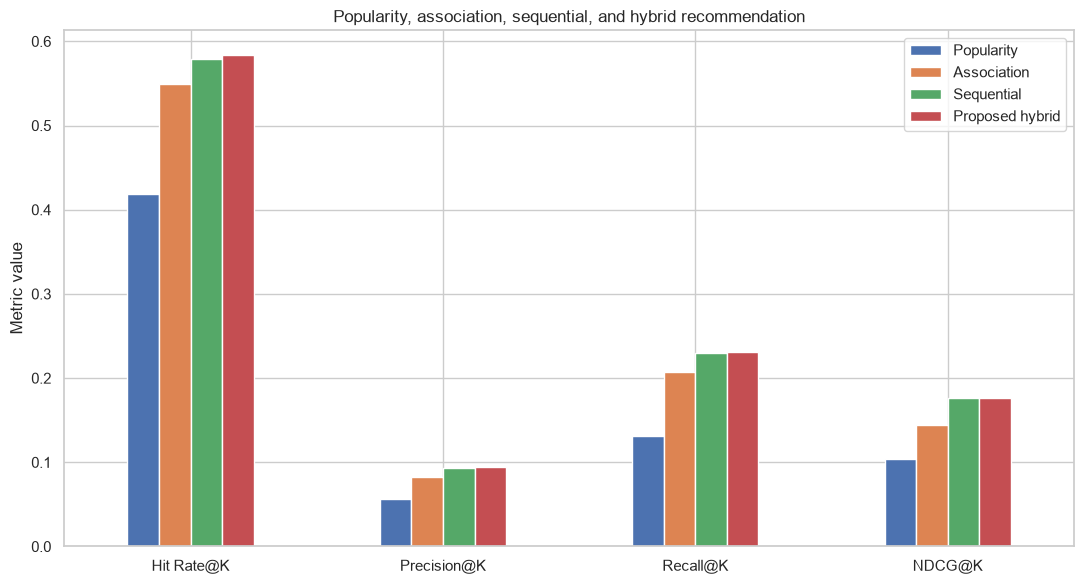

In [39]:
metric_names = [f"hit_rate@{TOP_K}", f"precision@{TOP_K}", f"recall@{TOP_K}", f"ndcg@{TOP_K}"]
comparison_plot = results.loc[metric_names].copy()
ax = comparison_plot.plot(kind="bar", figsize=(11, 6))
ax.set_ylabel("Metric value")
ax.set_title("Popularity, association, sequential, and hybrid recommendation")
ax.set_xticklabels(["Hit Rate@K", "Precision@K", "Recall@K", "NDCG@K"], rotation=0)
plt.tight_layout()
plt.show()


### 16. Inspect a recommendation explanation

For an academic prototype, recommendations should be explainable.

A recommendation can be explained using:

1. **Basket association:** the current basket matched an observed association rule.
2. **Customer history:** the customer has purchased the product previously.
3. **Recency:** the customer's previous purchase was relatively recent.
4. **Reorder tendency:** the product has appeared repeatedly in the customer's historical orders.

This is preferable to presenting a black-box score without evidence.


In [40]:
def explain_recommendation(user_id, items, k=TOP_K):
    recs = recommend_hybrid(
        user_id,
        items,
        k=k,
    )

    if recs.empty:
        return recs

    recs = recs.copy()

    def explanation(row):
        reasons = [
            f"association={row.association_score:.2f}",
            f"sequential={row.sequential_score:.2f}",
            f"type={row.recommendation_type}",
        ]

        if row.frequency_score > 0:
            reasons.append(
                f"customer bought it in "
                f"{row.frequency_score:.0%} of previous orders"
            )

        if pd.notna(row.gap_ratio):
            reasons.append(
                f"gap ratio={row.gap_ratio:.2f}"
            )

        if row.cadence_component > 0:
            reasons.append(
                f"cadence={row.cadence_component:.2f}"
            )

        return "; ".join(reasons)

    recs["explanation"] = recs.apply(
        explanation,
        axis=1,
    )

    return recs[
        [
            "product",
            "hybrid_score",
            "association_score",
            "sequential_score",
            "frequency_score",
            "cadence_component",
            "recommendation_type",
            "explanation",
        ]
    ]

display(
    explain_recommendation(
        example_user,
        example_basket_ids,
        k=TOP_K,
    )
)

,product,hybrid_score,association_score,sequential_score,frequency_score,cadence_component,recommendation_type,explanation
40,Bag of Organic Bananas,0.731224,1.000000,1.000000,0.222222,0.565402,REPEAT,association=1.00; sequential=1.00; type=REPEAT...
76,Organic Strawberries,0.283447,0.835955,0.163304,0.000000,0.000000,EXPLORE,association=0.84; sequential=0.16; type=EXPLORE
214,Organic Hass Avocado,0.182808,0.535386,0.110963,0.000000,0.000000,EXPLORE,association=0.54; sequential=0.11; type=EXPLORE
44,Organic Unsweetened Vanilla Almond Milk,0.157312,0.000000,0.014656,0.111111,0.393469,REPEAT,association=0.00; sequential=0.01; type=REPEAT...
127,Creamy Almond Butter,0.129852,0.000000,0.002094,0.111111,0.322190,REPEAT,association=0.00; sequential=0.00; type=REPEAT...
21,Clementines,0.107531,0.000000,0.537655,0.000000,0.000000,EXPLORE,association=0.00; sequential=0.54; type=EXPLORE
178,Bartlett Pears,0.103229,0.000000,0.008375,0.111111,0.242535,REPEAT,association=0.00; sequential=0.01; type=REPEAT...
53,Strawberries,0.085774,0.000000,0.428868,0.000000,0.000000,EXPLORE,association=0.00; sequential=0.43; type=EXPLORE
189,Raspberries,0.053137,0.000000,0.265687,0.000000,0.000000,EXPLORE,association=0.00; sequential=0.27; type=EXPLORE
82,Organic Baby Spinach,0.047698,0.000000,0.238490,0.000000,0.000000,EXPLORE,association=0.00; sequential=0.24; type=EXPLORE


## 17. Scalability and computational analysis

### Apriori

Apriori repeatedly generates and evaluates candidate itemsets. Its candidate space can grow rapidly as:

- number of products increases,
- basket size increases,
- minimum support decreases.

In the worst case, the itemset search space is exponential in the number of distinct items.

### FP-Growth

FP-Growth reduces explicit candidate generation by constructing a compressed FP-tree. It is often a stronger frequent-pattern baseline for larger transaction collections, but memory use can still become significant.

### Recommendation layer

Association-rule retrieval is relatively interpretable, but a production system would usually need:

- candidate filtering,
- inventory/availability constraints,
- store/location context,
- price/promotion signals,
- customer preferences,
- learned ranking,
- low-latency retrieval,
- distributed computation,
- online experimentation.

### Why this prototype is bounded

This notebook deliberately uses:

- a sampled number of orders,
- a top-product vocabulary,
- maximum itemset length,
- sparse storage.

Those controls make the academic experiment feasible on Colab/CPU.


In [41]:
# Simple empirical scalability table for the current sample.
# This is descriptive, not a theoretical complexity proof.

scalability_summary = pd.DataFrame({
    "factor": [
        "Mining orders",
        "Candidate products",
        "Minimum support",
        "Maximum itemset length",
        "Apriori runtime (s)",
        "FP-Growth runtime (s)",
        "Sparse basket density",
    ],
    "value": [
        mining_top.order_id.nunique(),
        mining_top.product_id.nunique(),
        MIN_SUPPORT,
        MAX_ITEMSET_LEN,
        apriori_seconds,
        fpgrowth_seconds,
        density,
    ],
})

display(scalability_summary)

,factor,value
0,Mining orders,24423.000000
1,Candidate products,250.000000
2,Minimum support,0.003000
3,Maximum itemset length,3.000000
4,Apriori runtime (s),0.895595
5,FP-Growth runtime (s),0.500318
6,Sparse basket density,0.016664


## 18. Responsible AI and data considerations

A real grocery recommendation system can affect what customers see and buy. The prototype should therefore consider:

- **Privacy:** minimize personally identifiable information and use aggregate identifiers where possible.
- **Exposure bias:** popular products can dominate recommendation metrics.
- **Availability:** never recommend products that are unavailable to the customer.
- **Fairness:** monitor whether certain products, brands, stores, or customer groups receive systematically different exposure.
- **Sensitive inference:** avoid using grocery behavior to infer sensitive personal attributes.
- **Feedback loops:** recommendations influence future purchases, which can reinforce existing popularity patterns.
- **Transparency:** provide understandable reasons for recommendations where appropriate.
- **Evaluation:** use offline metrics plus controlled online experiments before claiming business impact.


## 19. Industrial interpretation and Instacart connection

This notebook should be presented as a **course-aligned academic prototype**, not as a reconstruction of Instacart's private production stack.

The conceptual mapping is:

| Project layer | Purpose |
|---|---|
| Frequent itemset mining | Discover recurring product combinations |
| Association rules | Retrieve complementary candidate products |
| Customer history | Personalize candidates |
| Recency | Prioritize products relevant to recent behavior |
| Reorder signal | Capture repeat-purchase tendency |
| Ranking score | Combine global association and customer-specific evidence |
| Held-out evaluation | Test whether recommendations recover future purchases |

Instacart's public material can be used in the report to investigate its real recommendation/discovery architecture. The exact production algorithms should only be attributed to Instacart when supported by a credible public source.


## 20. What this notebook demonstrates for the IA-2 problem

### Approved problem statement

**Identifying complementary and potentially missing grocery products in a customer's shopping basket using frequent itemset mining, association rules, purchase history, and recency-aware recommendation.**

### Direct implementation mapping

| Required concept | Implemented? |
|---|---|
| Complementary products | âœ… Association-rule candidates |
| Potentially missing products | âœ… Products associated with basket but absent from it |
| Frequent itemset mining | âœ… Apriori + FP-Growth |
| Association rules | âœ… Support, confidence, lift |
| Customer shopping basket | âœ… Order-level basket |
| Purchase history | âœ… Customer-product history |
| Frequency | âœ… Previous-order frequency |
| Reorder behavior | âœ… Reorder tendency |
| Recency | âœ… Days since previous purchase |
| Personalized ranking | âœ… Rule + history + recency score |
| Next-basket prediction | âœ… Held-out last prior order |
| Evaluation | âœ… Hit@K, Precision@K, Recall@K, coverage, diversity |
| Scalability analysis | âœ… |
| Responsible AI | âœ… |

**Therefore, the notebook is directly aligned with the approved problem statement.**


## 21. Limitations and future improvements

### Current limitations

1. The public dataset is historical and does not represent all current Instacart users or products.
2. The prototype restricts the vocabulary to popular products for computational feasibility.
3. The scoring weights are manually selected rather than learned.
4. The evaluation uses next-basket overlap rather than real business outcomes.
5. Inventory, price, promotion, store, location, dietary preferences, and substitutions are not fully modeled.
6. Association rules are useful for candidate generation but are not sufficient as a complete production recommendation system.
7. The recency calculation is based on reconstructed elapsed time from the public order-history fields.

### Strong future improvements

- Learn ranking weights using logistic regression, gradient boosting, or a neural ranker.
- Add sequential pattern mining for ordered purchase behavior.
- Add product/category embeddings.
- Build a product co-occurrence graph.
- Add store/inventory/price context.
- Add diversity and novelty objectives.
- Compare against popularity and personalized-frequency baselines.
- Test different recency decay functions.
- Use cross-validation across users/time windows.
- Explore transformer/LLM-based semantic discovery as a separate retrieval/ranking layer.


## 22. Final conclusion

Frequent itemset mining provides an interpretable way to discover products that commonly occur together. Association rules convert these patterns into complementary-product candidates.

However, global co-occurrence alone does not answer the complete business problem. By incorporating a customer's purchase history, reorder behavior, and recency, the prototype moves from **generic basket completion** toward **personalized and recency-aware basket completion**.

The final architecture is therefore:

**Current Basket â†’ Frequent Patterns â†’ Association Candidates â†’ Customer History â†’ Recency/Reorder Signals â†’ Personalized Ranking â†’ Complementary/Potentially Missing Products â†’ Held-out Evaluation**

This layered design is the central contribution of the notebook.


## 23. References

1. Instacart Docs — Recommendations. https://docs.instacart.com/storefront/concepts/recommendations/
2. Instacart — 3 Million Instacart Orders, Open Sourced. https://tech.instacart.com/3-million-instacart-orders-open-sourced-d40d29ead6f2
3. Kaggle — Instacart Market Basket Analysis dataset. https://www.kaggle.com/competitions/instacart-market-basket-analysis/data
4. Instacart — Supercharging ML/AI Foundations at Instacart. https://company.instacart.com/tech-innovation/supercharging-ml-ai-foundations-at-instacart
5. Instacart — Distributed Machine Learning. https://company.instacart.com/tech-innovation/distributed-machine-learning-at-instacart
6. Instacart — Our Early Journey to Transform Instacart's Discovery Recommendations with LLMs. https://company.instacart.com/tech-innovation/our-early-journey-to-transform-instacart-s-discovery-recommendations-with-llms
7. Agrawal et al. (1993). Mining Association Rules Between Sets of Items in Large Databases. https://doi.org/10.1145/170035.170072
8. Han et al. (2000). Mining Frequent Patterns without Candidate Generation. https://doi.org/10.1145/342009.335372
9. NBRR — An Empirical Study and a Proposed Approach. https://github.com/NextBasketRepurchaseRecommendation/NBRR-an-Empirical-Study-and-a-Proposed-Approach
10. RecSys next-novel-basket research. https://arxiv.org/abs/2308.01308

These sources motivate the distinction between association, sequential behaviour, repeat/explore recommendations, and personalized cadence. They are research context, not evidence that the public notebook reproduces Instacart's proprietary system.


# 21. AI usage declaration

ChatGPT/Codex was used for literature-search planning, code scaffolding, explanations, debugging support, and editorial review. Students should execute the notebook, inspect the outputs, understand the algorithms and results, verify all external claims against the cited sources, and adapt this declaration to accurately describe their own use.

**Do not claim that Apriori or FP-Growth are Instacart's production algorithms unless a cited source explicitly establishes that fact.**
